In [149]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import cv2

from src.preprocessing import preprocess_image
from src.utils import show_image, show_images_grid


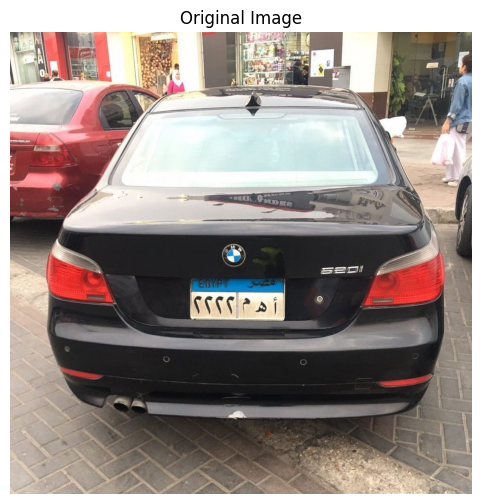

In [150]:
image_path = PROJECT_ROOT / "Data" / "test_images" / "0593.jpg"

image = cv2.imread(str(image_path))

if image is None:
    raise ValueError("Image not found. Check the image path.")

show_image("Original Image", image)

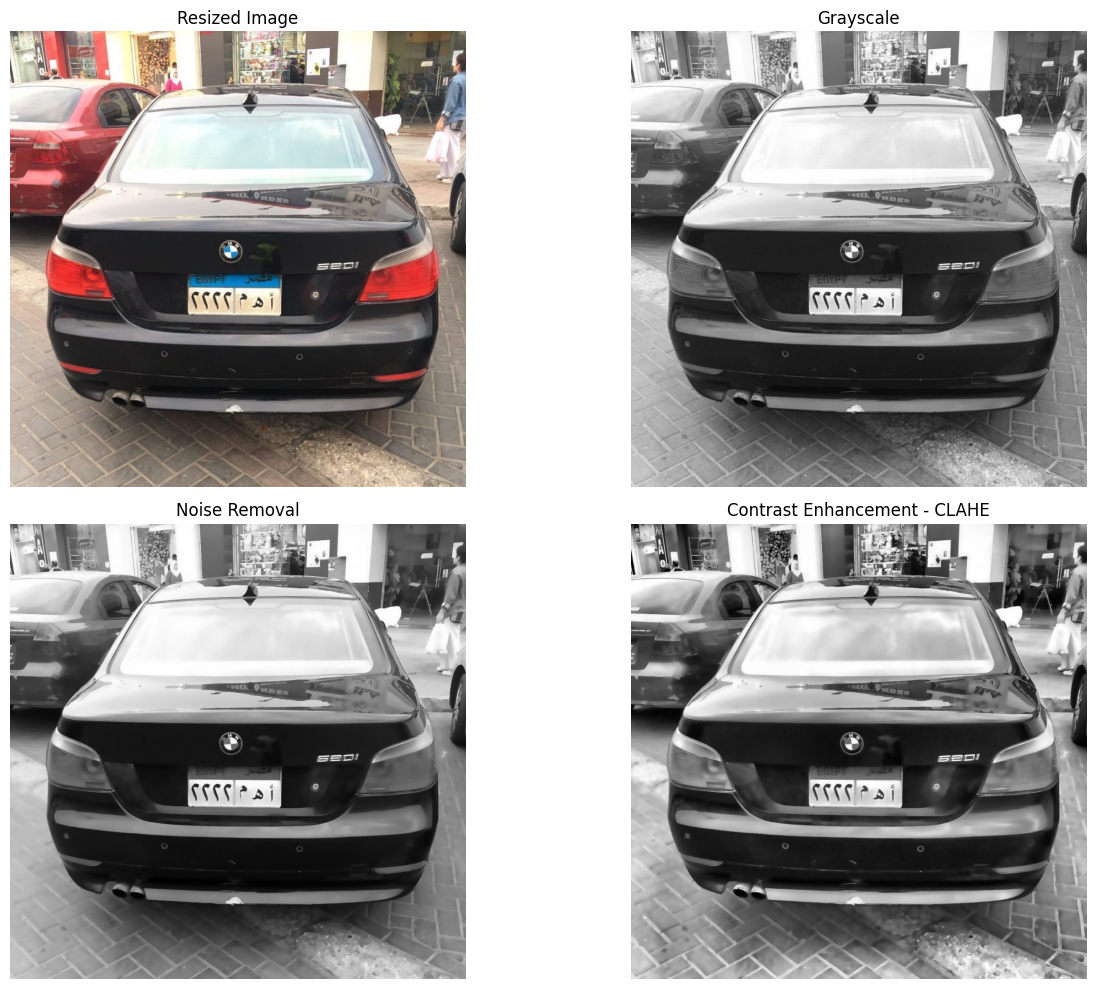

In [151]:
preprocessed = preprocess_image(image, width=900)

show_images_grid({
    "Resized Image": preprocessed["resized"],
    "Grayscale": preprocessed["gray"],
    "Noise Removal": preprocessed["denoised"],
    "Contrast Enhancement - CLAHE": preprocessed["enhanced"]
}, cols=2, figsize=(14, 10))

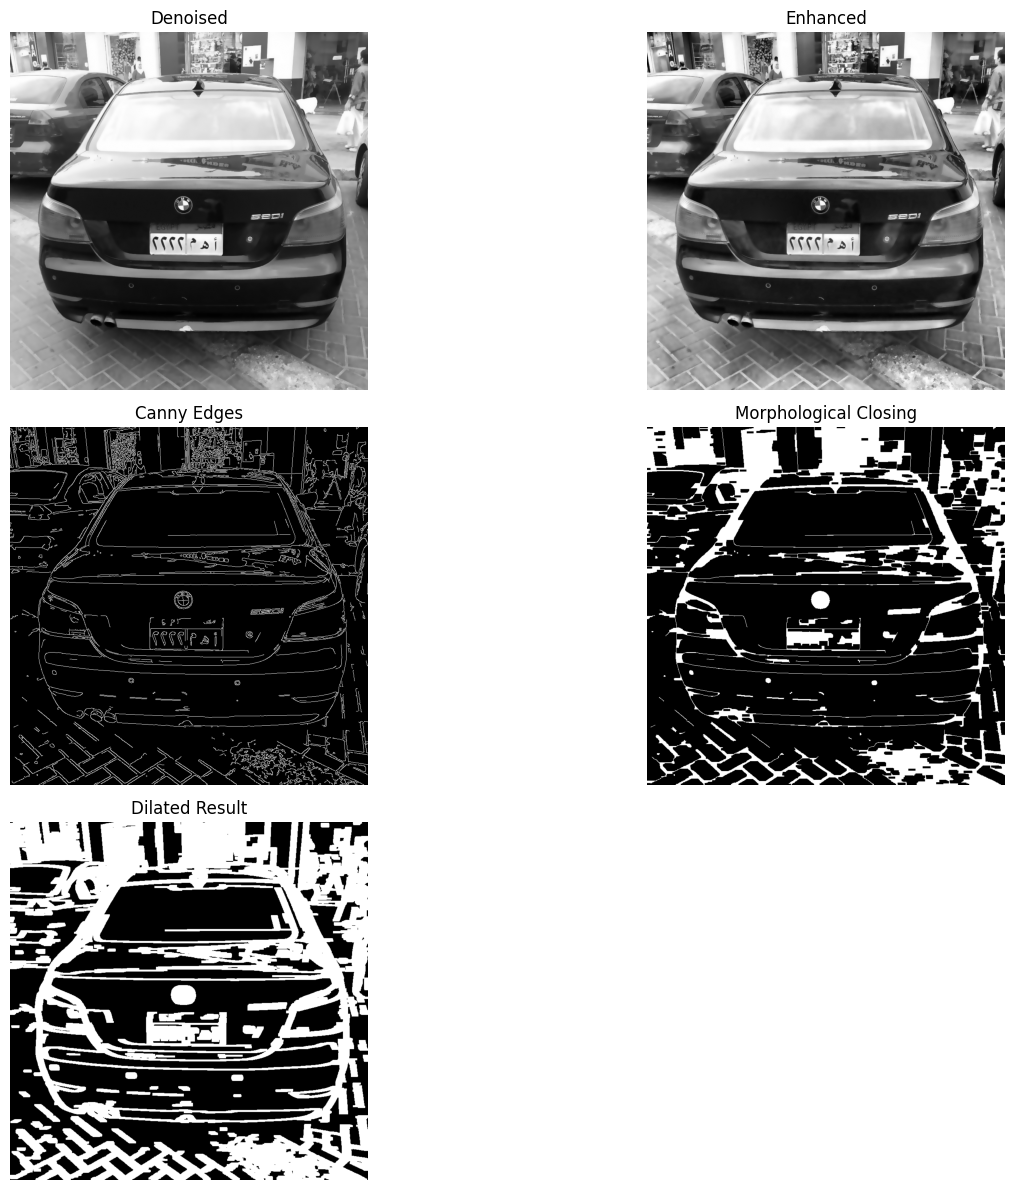

Lower Threshold: 84
Upper Threshold: 170


In [152]:
from src.detection import canny_pipeline
from src.utils import show_images_grid

gray = preprocessed["gray"]

canny_output = canny_pipeline(gray)

show_images_grid({
    "Denoised": canny_output["denoised"],
    "Enhanced": canny_output["enhanced"],
    "Canny Edges": canny_output["edges"],
    "Morphological Closing": canny_output["closed"],
    "Dilated Result": canny_output["dilated"]
}, cols=2, figsize=(14, 12))

print("Lower Threshold:", canny_output["lower_threshold"])
print("Upper Threshold:", canny_output["upper_threshold"])

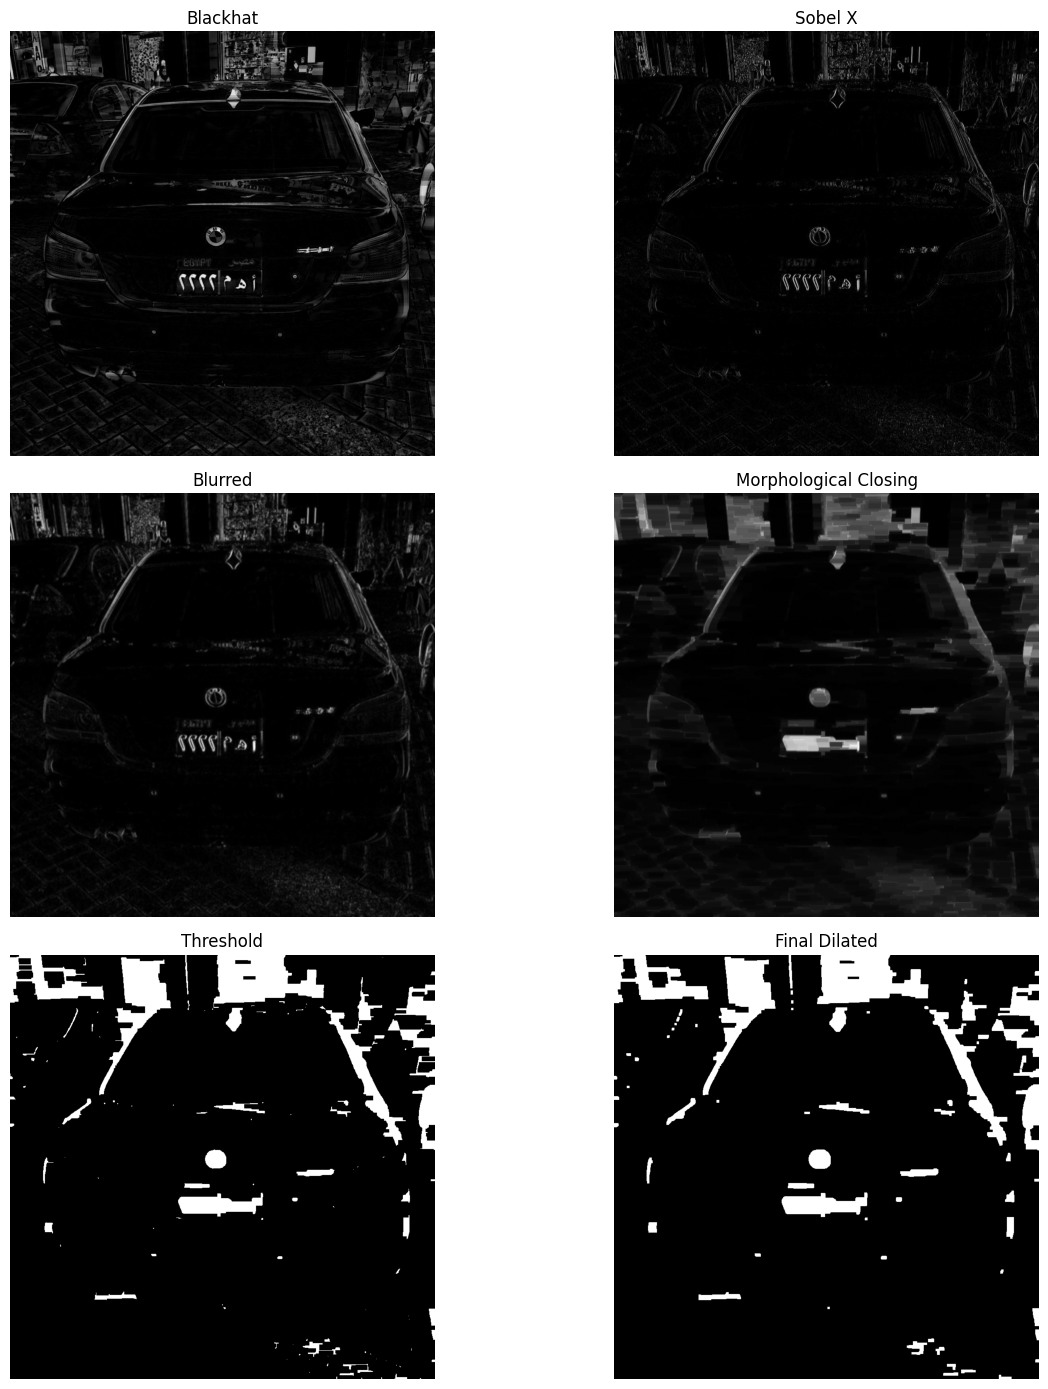

In [153]:
from src.detection import blackhat_pipeline

blackhat_output = blackhat_pipeline(gray)

show_images_grid({
    "Blackhat": blackhat_output["blackhat"],
    "Sobel X": blackhat_output["sobel_x"],
    "Blurred": blackhat_output["blurred"],
    "Morphological Closing": blackhat_output["closed"],
    "Threshold": blackhat_output["threshold"],
    "Final Dilated": blackhat_output["dilated"]
}, cols=2, figsize=(14, 14))

In [157]:
import src.detection as d

importlib.reload(d)

dir(d)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'blackhat_pipeline',
 'canny_pipeline',
 'cv2',
 'draw_candidates',
 'enhance_contrast',
 'extract_candidates',
 'np',
 'remove_noise']

Number of Blackhat Candidates: 8


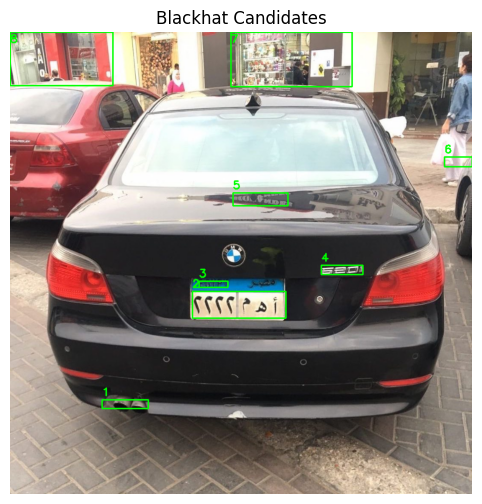

In [160]:
blackhat_candidates = extract_candidates(
    blackhat_output["dilated"],
    resized
)

print("Number of Blackhat Candidates:", len(blackhat_candidates))

blackhat_candidates_image = draw_candidates(
    resized,
    blackhat_candidates
)

show_image("Blackhat Candidates", blackhat_candidates_image)

Number of Canny Candidates: 5


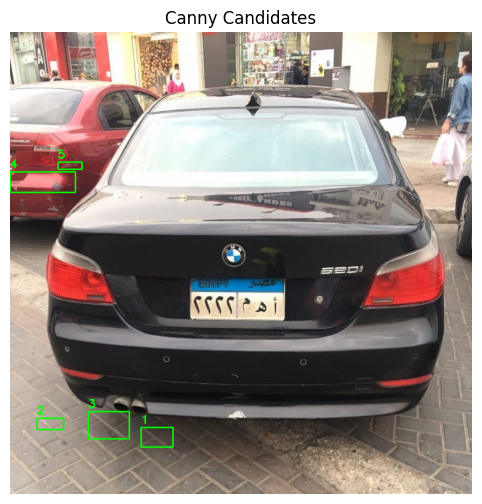

In [158]:
from src.detection import extract_candidates, draw_candidates
from src.utils import show_image

resized = preprocessed["resized"]

canny_candidates = extract_candidates(
    canny_output["dilated"],
    resized
)

print("Number of Canny Candidates:", len(canny_candidates))

canny_candidates_image = draw_candidates(
    resized,
    canny_candidates
)

show_image("Canny Candidates", canny_candidates_image)

All Candidates: 13


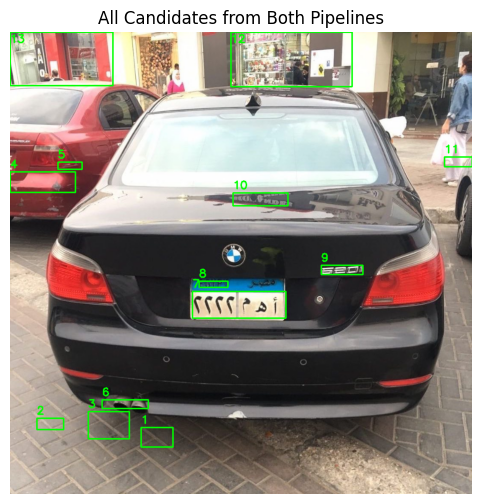

In [161]:
all_candidates = canny_candidates + blackhat_candidates

print("All Candidates:", len(all_candidates))

all_candidates_image = draw_candidates(
    resized,
    all_candidates
)

show_image("All Candidates from Both Pipelines", all_candidates_image)

Candidate 1
Box: (255, 770, 62, 38)
Aspect Ratio: 1.63
Area Ratio: 0.0029
Extent: 0.34
----------------------------------------


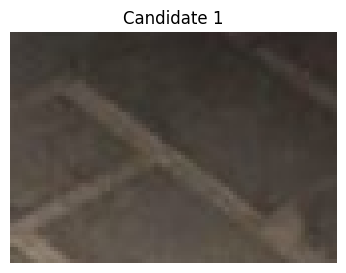

Candidate 2
Box: (52, 752, 52, 22)
Aspect Ratio: 2.36
Area Ratio: 0.0014
Extent: 0.51
----------------------------------------


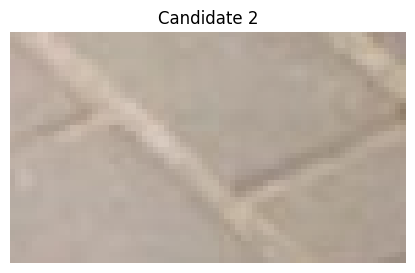

Candidate 3
Box: (152, 739, 80, 53)
Aspect Ratio: 1.51
Area Ratio: 0.0052
Extent: 0.35
----------------------------------------


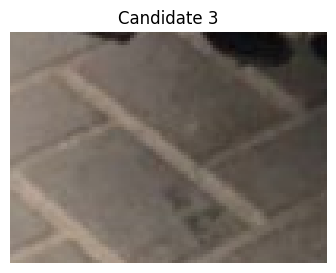

Candidate 4
Box: (0, 272, 127, 40)
Aspect Ratio: 3.17
Area Ratio: 0.0063
Extent: 0.48
----------------------------------------


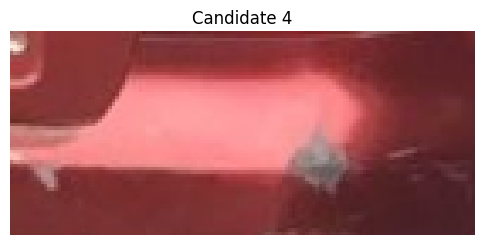

Candidate 5
Box: (93, 253, 47, 14)
Aspect Ratio: 3.36
Area Ratio: 0.0008
Extent: 0.7
----------------------------------------


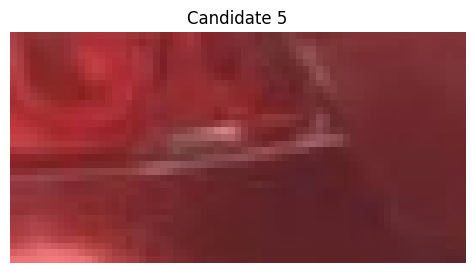

Candidate 6
Box: (179, 716, 90, 17)
Aspect Ratio: 5.29
Area Ratio: 0.0019
Extent: 0.56
----------------------------------------


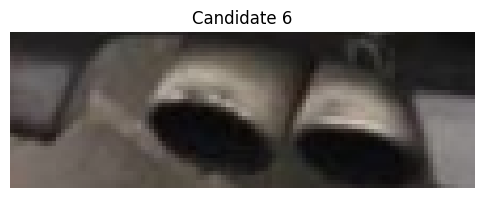

Candidate 7
Box: (355, 505, 182, 52)
Aspect Ratio: 3.5
Area Ratio: 0.0117
Extent: 0.6
----------------------------------------


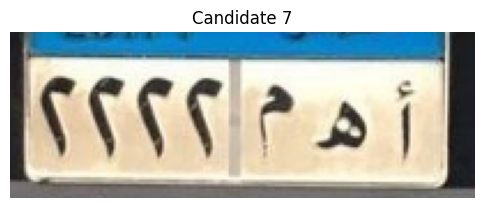

Candidate 8
Box: (368, 485, 56, 12)
Aspect Ratio: 4.67
Area Ratio: 0.0008
Extent: 0.83
----------------------------------------


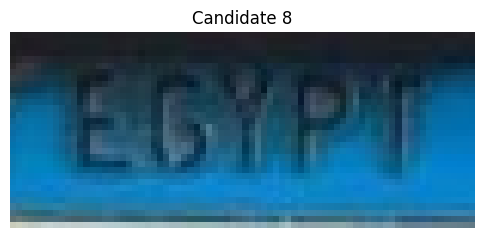

Candidate 9
Box: (606, 454, 81, 18)
Aspect Ratio: 4.5
Area Ratio: 0.0018
Extent: 0.67
----------------------------------------


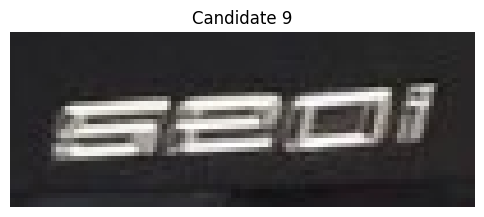

Candidate 10
Box: (434, 313, 107, 25)
Aspect Ratio: 4.28
Area Ratio: 0.0033
Extent: 0.35
----------------------------------------


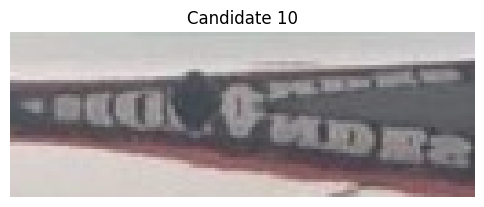

In [162]:
from src.utils import crop_with_padding, show_image

for i, candidate in enumerate(all_candidates[:10]):
    crop = crop_with_padding(
        resized,
        candidate["box"],
        padding=10
    )

    print(f"Candidate {i + 1}")
    print("Box:", candidate["box"])
    print("Aspect Ratio:", round(candidate["aspect_ratio"], 2))
    print("Area Ratio:", round(candidate["area_ratio"], 4))
    print("Extent:", round(candidate["extent"], 2))
    print("-" * 40)

    show_image(
        f"Candidate {i + 1}",
        crop,
        figsize=(6, 3)
    )